## Bem-vindo à Semana 4, Dia 4

Este é o início de um projeto INCRÍVEL! Muito simples e muito eficaz.

In [ ]:
!node --version

v22.15.0


In [8]:
!npx --version

11.3.0


In [1]:
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START
from langgraph.graph.message import add_messages
from dotenv import load_dotenv
from IPython.display import Image, display
import gradio as gr
from langgraph.prebuilt import ToolNode, tools_condition
import requests
import os
from langchain.agents import Tool

from langchain_openai import ChatOpenAI
from langgraph.checkpoint.memory import MemorySaver

In [2]:
load_dotenv(override=True)

True

### LangGraph Assíncrono

Para executar uma ferramenta:  
Síncrono: `tool.run(inputs)`  
Assíncrono: `await tool.arun(inputs)`

Para invocar o grafo:  
Síncrono: `graph.invoke(state)`  
Assíncrono: `await graph.ainvoke(state)`

In [3]:
class State(TypedDict):
    
    messages: Annotated[list, add_messages]


graph_builder = StateGraph(State)

In [4]:
pushover_token = os.getenv("PUSHOVER_TOKEN")
pushover_user = os.getenv("PUSHOVER_USER")
pushover_url = "https://api.pushover.net/1/messages.json"

def push(text: str):
    """Enviar uma notificação push para o usuário"""
    requests.post(pushover_url, data = {"token": pushover_token, "user": pushover_user, "message": text})

tool_push = Tool(
        name="send_push_notification",
        func=push,
        description="útil quando você quiser enviar uma notificação push"
    )

## Passo extra de instalação - se você não tiver Node e Playwright no seu computador

Em seguida, você precisa instalar NodeJS e Playwright no seu computador se ainda não tiver. Consulte as instruções aqui:

[Configuração de Node e Playwright](../setup/SETUP-node.md)


## E agora - depois de instalar o Playwright, um aviso para usuários de PC com Windows:

Ao executar as próximas células, você pode encontrar um problema com o navegador do Playwright gerando um NotImplementedError.

Isso deve funcionar quando migrarmos para módulos Python, mas pode causar problemas no Windows dentro de um notebook.

Se você encontrar esse erro e quiser rodar o notebook, precisa fazer uma pequena alteração que parece bem hacky! Faça isso APÓS instalar o Playwright (células anteriores)

1. Clique com o botão direito em `.venv` no Explorador de Arquivos à esquerda e selecione "Find in folder"
2. Pesquise por `asyncio.set_event_loop_policy(WindowsSelectorEventLoopPolicy())`  
3. Esse código deve aparecer em uma linha dentro de um arquivo chamado `kernelapp.py`
4. Comente todo o bloco else do qual essa linha faz parte - veja o trecho abaixo. Certifique-se de manter a instrução "pass" após a linha do ImportError.
5. Reinicie o kernel pressionando o botão "Restart" acima

```python
        if sys.platform.startswith("win") and sys.version_info >= (3, 8):
            import asyncio
 
            try:
                from asyncio import WindowsProactorEventLoopPolicy, WindowsSelectorEventLoopPolicy
            except ImportError:
                pass
                # not affected
           # else:
            #    if type(asyncio.get_event_loop_policy()) is WindowsProactorEventLoopPolicy:
                    # WindowsProactorEventLoopPolicy is not compatible with tornado 6
                    # fallback to the pre-3.8 default of Selector
                    # asyncio.set_event_loop_policy(WindowsSelectorEventLoopPolicy())
```

Obrigado ao aluno Nicolas por descobrir isso, e a Kalyan, Yaki, Zibin e Bhaskar por confirmarem que funcionou para eles! E ao Vladislav pelas dicas extras.

Como alternativa, você pode simplesmente migrar para um módulo Python (o que faremos de qualquer forma no Dia 5)


In [5]:
# Apresentando o nest_asyncio
# O código assíncrono em Python só permite um único "event loop" processando eventos assíncronos.
# A biblioteca `nest_asyncio` corrige isso e é usada em situações especiais, quando você precisa executar um event loop aninhado.

import nest_asyncio
nest_asyncio.apply()

### A comunidade LangChain

Uma das coisas notáveis sobre o LangChain é a comunidade vibrante ao seu redor.

Confira:


In [6]:
from langchain_community.agent_toolkits import PlayWrightBrowserToolkit
from langchain_community.tools.playwright.utils import create_async_playwright_browser

# Se você receber um NotImplementedError aqui ou mais adiante, consulte o aviso no topo do notebook

async_browser =  create_async_playwright_browser(headless=False)  # headful mode
toolkit = PlayWrightBrowserToolkit.from_browser(async_browser=async_browser)
tools = toolkit.get_tools()

In [7]:
for tool in tools:
    print(f"{tool.name}={tool}")

click_element=async_browser=<Browser type=<BrowserType name=chromium executable_path=/home/santclear/.cache/ms-playwright/chromium-1169/chrome-linux/chrome> version=136.0.7103.25>
navigate_browser=async_browser=<Browser type=<BrowserType name=chromium executable_path=/home/santclear/.cache/ms-playwright/chromium-1169/chrome-linux/chrome> version=136.0.7103.25>
previous_webpage=async_browser=<Browser type=<BrowserType name=chromium executable_path=/home/santclear/.cache/ms-playwright/chromium-1169/chrome-linux/chrome> version=136.0.7103.25>
extract_text=async_browser=<Browser type=<BrowserType name=chromium executable_path=/home/santclear/.cache/ms-playwright/chromium-1169/chrome-linux/chrome> version=136.0.7103.25>
extract_hyperlinks=async_browser=<Browser type=<BrowserType name=chromium executable_path=/home/santclear/.cache/ms-playwright/chromium-1169/chrome-linux/chrome> version=136.0.7103.25>
get_elements=async_browser=<Browser type=<BrowserType name=chromium executable_path=/home/

In [14]:
tool_dict = {tool.name:tool for tool in tools}

navigate_tool = tool_dict.get("navigate_browser")
extract_text_tool = tool_dict.get("extract_text")

    
await navigate_tool.arun({"url": "https://www.cnn.com"})
text = await extract_text_tool.arun({})

In [15]:
import textwrap
print(textwrap.fill(text))

Breaking News, Latest News and Videos | CNN CNN values your feedback
1. How relevant is this ad to you? 2. Did you encounter any technical
issues? No Video player was slow to load content Video content never
loaded Ad froze or did not finish loading Video content did not start
after ad Audio on ad was too loud Other issues Ad never loaded Ad
prevented/slowed the page from loading Content moved around while ad
loaded Ad was repetitive to ads I've seen previously Other issues
Cancel Submit Thank You! Your effort and contribution in providing
this feedback is much
appreciated. Close Ad Feedback Close icon US World Politics Business
Health Entertainment Style Travel Sports Science Climate Weather
Ukraine-Russia War Israel-Hamas War Games More US World Politics
Business Health Entertainment Style Travel Sports Science Climate
Weather Ukraine-Russia War Israel-Hamas War Games Watch Listen Live TV
Subscribe Sign in My Account Settings Newsletters Topics you follow
Sign out Your CNN account Si

In [16]:
all_tools = tools + [tool_push]

In [17]:

llm = ChatOpenAI(model="gpt-5-mini")
llm_with_tools = llm.bind_tools(all_tools)


def chatbot(state: State):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}


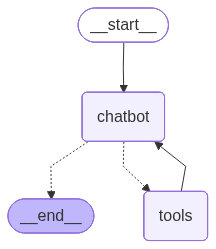

In [18]:

graph_builder = StateGraph(State)
graph_builder.add_node("chatbot", chatbot)
graph_builder.add_node("tools", ToolNode(tools=all_tools))
graph_builder.add_conditional_edges( "chatbot", tools_condition, "tools")
graph_builder.add_edge("tools", "chatbot")
graph_builder.add_edge(START, "chatbot")

memory = MemorySaver()
graph = graph_builder.compile(checkpointer=memory)
display(Image(graph.get_graph().draw_mermaid_png()))

In [19]:
config = {"configurable": {"thread_id": "10"}}

async def chat(user_input: str, history):
    result = await graph.ainvoke({"messages": [{"role": "user", "content": user_input}]}, config=config)
    return result["messages"][-1].content


gr.ChatInterface(chat, type="messages").launch()

* Running on local URL:  http://127.0.0.1:7861
* To create a public link, set `share=True` in `launch()`.
